# CHAPTER 2 - The Tools of the Trade in Quantum Computing - Qiskit Code

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np

## Quantum circuits

In [2]:
qreg1 = QuantumRegister(size = 2, name = "qrg1")
qreg2 = QuantumRegister(1, "qrg2")
creg = ClassicalRegister(1, "oldschool")

qc = QuantumCircuit(qreg1, creg, qreg2)

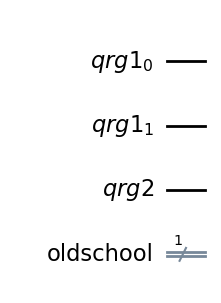

In [3]:
qc.draw('mpl')

## Draw a Quantum Circuit

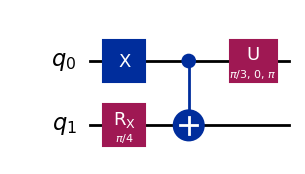

In [4]:
import numpy as np

qc = QuantumCircuit(2) # Initialise the circuit.

# We can now apply the gates sequentially.
qc.x(0)
qc.rx(np.pi/4, 1)
qc.cx(0, 1)
qc.u(np.pi/3, 0, np.pi, 0)

qc.draw("mpl")

### Visualize the state vectors

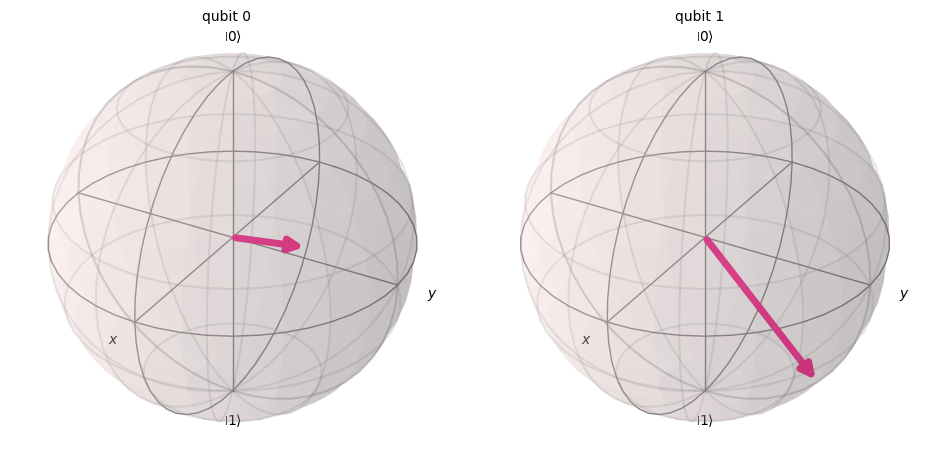

In [5]:
sv = Statevector(qc)
plot_bloch_multivector(sv)

## Visualize Bell state circuit

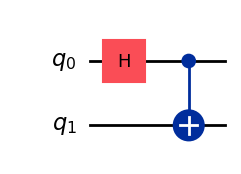

In [6]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

qc.draw('mpl')

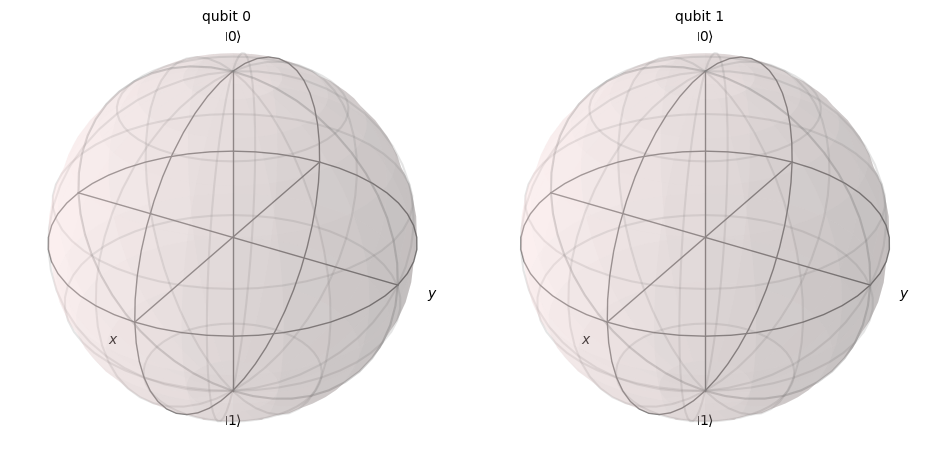

In [7]:
sv = Statevector(qc)
plot_bloch_multivector(sv)
# no state vector is shown on Bloch sphere since the Bell State is entangled

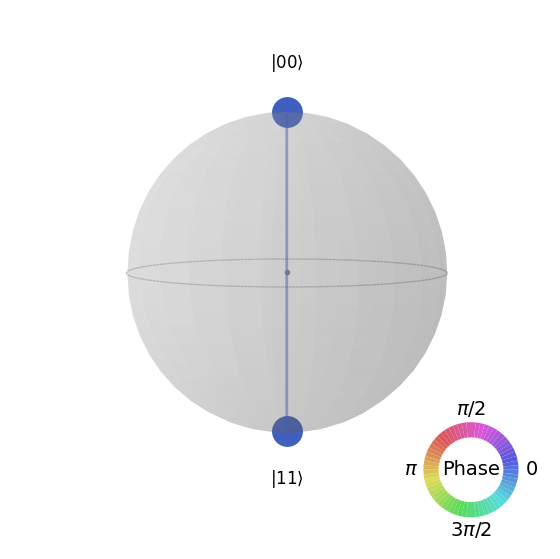

In [8]:
# q-sphere is useful when Bloch sphere fails
plot_state_qsphere(sv)

## Run a quantum circuit on a simulator

In [9]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator

In [10]:
backend = GenericBackendV2(num_qubits=10)

In [11]:
qc = QuantumCircuit(2, 2)
qc.h(0)
#qc.save_statevector()
qc.measure_all()

#### We use AER Simulator

In [12]:
seed_sim = 42
sim = AerSimulator.from_backend(backend, seed_simulator=seed_sim)

### Transpile the quantum circuit using pass manager

In [13]:
pm = generate_preset_pass_manager(backend=sim, optimization_level=2)

Transpiled circuit


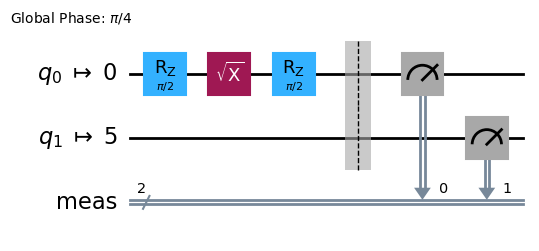

In [14]:
isa_circuit = pm.run(qc)
print("Transpiled circuit")
isa_circuit.draw('mpl', idle_wires=False)

In [15]:
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('rz', 2), ('measure', 2), ('sx', 1), ('barrier', 1)])


### Sampler

In [16]:
sampler = Sampler(mode=sim)

In [17]:
job_sampler = sampler.run([isa_circuit], shots=1024)

In [18]:
result_sampler = job_sampler.result()
print(result_sampler)

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>), meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [19]:
pub_result = result_sampler[0]

In [20]:
counts = pub_result.data.meas.get_counts()

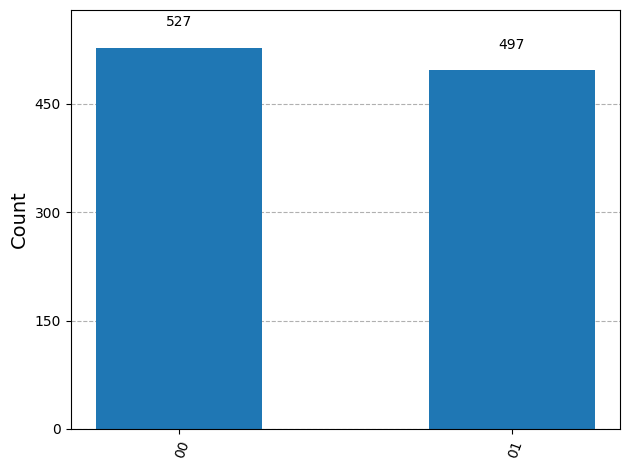

In [21]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

### Simulator with noise profile similar to real backend

In [22]:
service = QiskitRuntimeService()

/tmp/ipykernel_33806/1875822867.py:1: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService()


In [23]:
# List service backends
service.backends()

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_sherbrooke')>]

In [24]:
# With noise
real_backend = service.backend("ibm_brisbane")
aer_sim = AerSimulator.from_backend(real_backend)

In [25]:
import re
dev_name = re.search(r"\(.*?\)", aer_sim.name).group(0) 
print(dev_name)

(ibm_brisbane)


#### Transpile the circuit to match the topology of the selected quantum device

In [26]:
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

In [27]:
isa_qc = pm.run(qc)

In [28]:
result_sim = sampler.run([isa_qc], shots=1024).result()

In [29]:
counts_sim = result_sim[0].data.meas.get_counts()

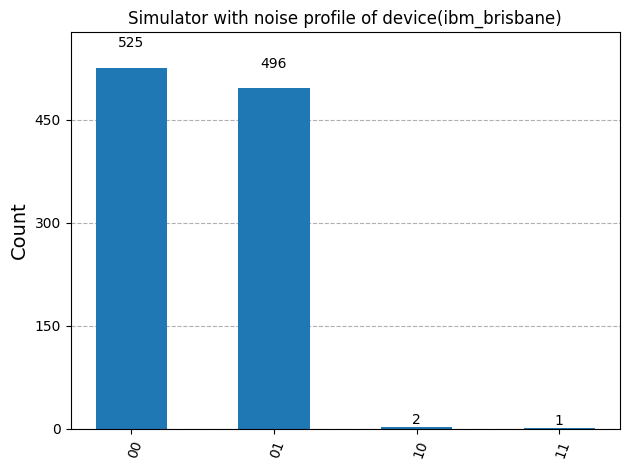

In [30]:
plot_histogram(counts_sim, title=f"Simulator with noise profile of device{dev_name}")

### Run on real HW

In [31]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [32]:
# Only need to do following once

# copy token in your .bashrc or .zshrc
# export IQP_API_TOKEN="<YOUR_API_TOKEN>"

# import os
# ibm_token = os.environ['IQP_API_TOKEN'] 

#QiskitRuntimeService.save_account(
#  token=ibm_token,
#  channel="ibm_quantum", # `channel` distinguishes between different account types
#  overwrite=True         # set to True if the token needs to be updated with a new token
#)

In [33]:
dev_list = service.backends(
    filters = lambda x: x.configuration().n_qubits >= 5,
    simulator = False)

In [34]:
print(dev_list)

[<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_sherbrooke')>]


In [35]:
# Select least busy backend
dev = service.least_busy(min_num_qubits=5, simulator=False, operational=True)
print(dev)

<IBMBackend('ibm_brisbane')>


#### Use simulator to generate results similar to the selected backend

In [36]:
seed_sim = 42
sim = AerSimulator.from_backend(dev, seed_simulator=seed_sim)
print(sim)

AerSimulator('aer_simulator_from(ibm_brisbane)'
             noise_model=<NoiseModel on ['sx', 'x', 'measure', 'ecr', 'reset', 'id']>)


#### Start with a simple circuit

In [37]:
# Let us set up a simple circuit.
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

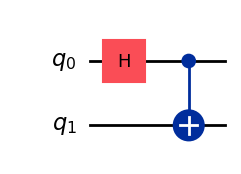

In [38]:
qc.draw('mpl')

In [39]:
# Measure all qubits
qc.measure_all()

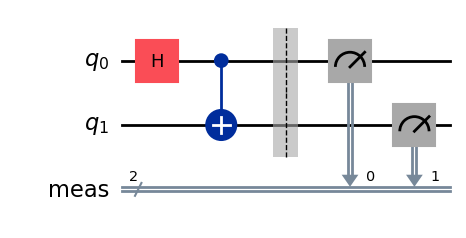

In [40]:
qc.draw('mpl')

In [41]:
# First, we run the circuit using the statevector simulator.
pm = generate_preset_pass_manager(backend=sim, optimization_level=1)
isa_qc = pm.run(qc)

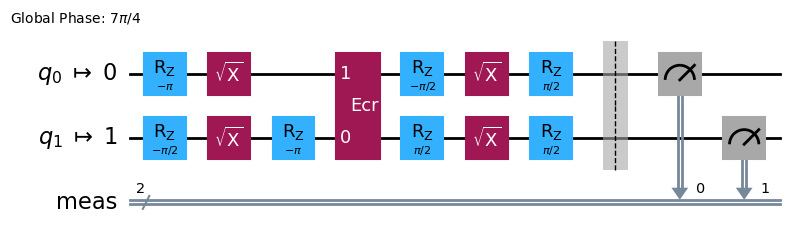

In [42]:
isa_qc.draw('mpl')

In [43]:
sampler = Sampler(mode=sim)
result_sim = sampler.run([isa_qc], shots=1024).result()

In [44]:
print(result_sim)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [45]:
counts_sim = result_sim[0].data.meas.get_counts()

In [46]:
# Now we run it on the real device that we selected before.
sampler = Sampler(mode=dev)
result_dev = sampler.run([isa_qc], shots=1024).result()

/home/pranjal/git_repos/qml/A-Practical-Guide-to-Quantum-Machine-Learning-and-Quantum-Optimization/.venv/lib/python3.11/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


In [47]:
counts_dev = result_dev[0].data.meas.get_counts()

In [48]:
print(counts_sim)
print(counts_dev)

{'11': 462, '00': 481, '01': 40, '10': 41}
{'11': 483, '00': 504, '01': 23, '10': 14}


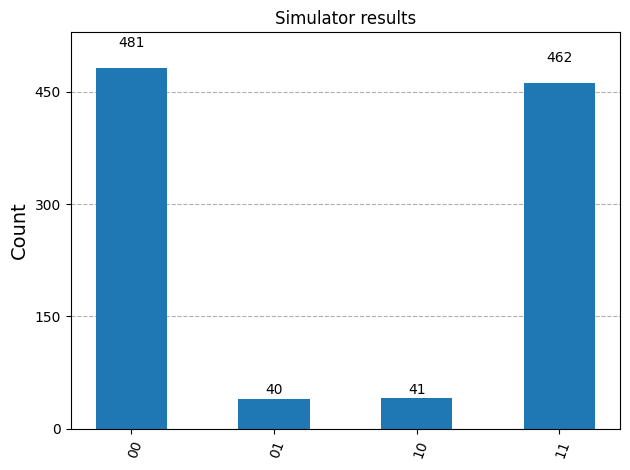

In [49]:
plot_histogram(counts_sim, title="Simulator results")

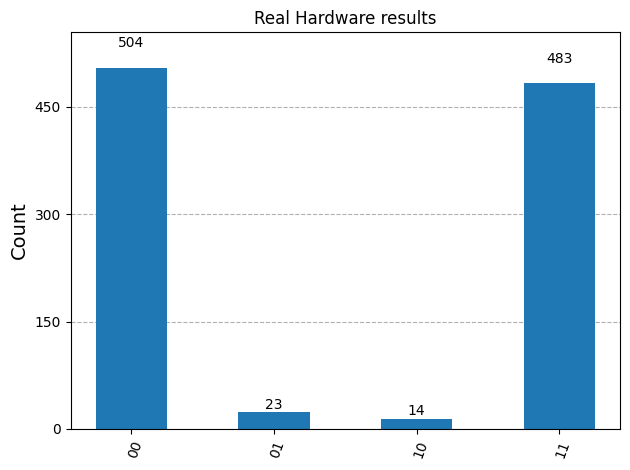

In [50]:
plot_histogram(counts_dev, title="Real Hardware results")